# Experimento 6: BioLinkBERT-base para Relation Extraction

**Objetivo:** Comparar BioLinkBERT-base con PubMedBERT usando exactamente la misma configuracion que el Experimento 1.

**Hipotesis:** BioLinkBERT fue entrenado no solo con texto biomedico sino tambien modelando los **enlaces** entre documentos de PubMed (como si supiera que articulos citan a otros). Esto le da una comprension mas rica de las conexiones entre conceptos, lo que deberia ser especialmente util para relation extraction.

**Diferencia con Exp1:** Solo cambia el backbone. Todo lo demas (datos, hiperparametros, arquitectura) es identico para que la comparacion sea justa.

**Resultados anteriores:**
- Baseline (bert-multilingual, 10ep): Macro F1 = 0.6944
- Exp1: PubMedBERT (10ep): Macro F1 = 0.7754
- Exp2: PubMedBERT + typed markers (15ep): Macro F1 = 0.8078
- Exp3: PubMedBERT + typed markers + neg_ratio 1:1 (15ep): Macro F1 = 0.8430

**Modelo a probar:** `michiyasunaga/BioLinkBERT-base`

**Referencia bibliografica:** Sanger & Leser, BMC Bioinformatics 2025 — BioLinkBERT-large es el mejor modelo en todos los datasets de RE biomedica evaluados.

## 1. Setup e Instalacion

In [2]:
# Ejecutar solo la primera vez
!pip install git+https://github.com/thunlp/OpenNRE.git
!pip install torch transformers nltk pandas scikit-learn matplotlib seaborn

  Cloning https://github.com/thunlp/OpenNRE.git to /tmp/pip-req-build-nw4ukzsa
  Running command git clone --filter=blob:none --quiet https://github.com/thunlp/OpenNRE.git /tmp/pip-req-build-nw4ukzsa
  Resolved https://github.com/thunlp/OpenNRE.git to commit 8e42fd712f2ab01b48a7e7c4cb2bdea45ec6ff9a
  Preparing metadata (setup.py) ... done
  Created wheel for open-nre: filename=open_nre-0.1.1-py3-none-any.whl size=41950 sha256=67381ab6fbe8664f2c3d56c69a356db44d6914f939f97138197430754622a884
  Stored in directory: /tmp/pip-ephem-wheel-cache-o0o_4cr1/wheels/ea/ef/3b/4c1a3b1e8f2c5bdbe5961c073dd67f822110066ee2a43bb635
Successfully built open-nre
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.1 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the pa

In [3]:
import json
import importlib
import time
import logging
import os
from collections import Counter
from pathlib import Path

import nltk
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("transformers").setLevel(logging.ERROR)
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import opennre

try:
    nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    nltk.download("punkt_tab", quiet=True)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.10.0+cu128
CUDA disponible: True
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Configuracion del Experimento

La unica diferencia con Exp1 es `MODEL_NAME`. Todo lo demas es identico.

In [6]:
# ============================================================
# CONFIGURACION - EXPERIMENTO 6: BioLinkBERT-base
# ============================================================

# *** UNICO CAMBIO RESPECTO A EXP1 ***
MODEL_NAME = "michiyasunaga/BioLinkBERT-base"
EXPERIMENT_NAME = "biolinkbert_base"

# Por que BioLinkBERT?
# - Entrenado con PubMed + enlaces entre documentos (document linking)
# - Entiende conexiones entre conceptos biomedicos mejor que PubMedBERT
# - Sanger & Leser 2025 (BMC Bioinformatics): mejor modelo en 5/5 datasets de RE biomedica
# - La version base tiene ~110M params (igual que PubMedBERT), sin problemas de VRAM en T4

# HIPERPARAMETROS (identicos a Exp1)
MAX_LENGTH = 256
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 10
WARMUP_STEPS = 300
SEED = 42
NEG_RATIO = 3  # igual que Exp1, datos originales sin modificar

# Paths Kaggle
DATA_DIR = Path("/kaggle/input/datasets/lucaespernjj/bionner-data")
TRAIN_DATA = DATA_DIR / "eng_train.txt"
DEV_DATA = DATA_DIR / "eng_dev.txt"
REL2ID_PATH = DATA_DIR / "rel2id.json"

# Outputs
OUTPUT_DIR = Path("/kaggle/working/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = OUTPUT_DIR / f"eng_{EXPERIMENT_NAME}.pth.tar"
PRED_PATH = OUTPUT_DIR / f"eng_pred_{EXPERIMENT_NAME}.tsv"

RELATION_TYPES = [
    "ABBREVIATION", "ALTERNATIVE_NAME", "SUBCLASS_OF", "PART_OF",
    "TREATED_USING", "ORIGINS_FROM", "TO_DETECT_OR_STUDY", "AFFECTS",
    "HAS_CAUSE", "APPLIED_TO", "USED_IN", "ASSOCIATED_WITH",
    "PHYSIOLOGY_OF", "FINDING_OF",
    "no_relation",
]

with open(REL2ID_PATH) as f:
    rel2id = json.load(f)

print(f"Experimento: {EXPERIMENT_NAME}")
print(f"Modelo: {MODEL_NAME}")
print(f"Checkpoint: {CKPT_PATH}")
print(f"Clases: {len(RELATION_TYPES)} (14 relaciones + no_relation)")

Experimento: biolinkbert_base
Modelo: michiyasunaga/BioLinkBERT-base
Checkpoint: /kaggle/working/outputs/eng_biolinkbert_base.pth.tar
Clases: 15 (14 relaciones + no_relation)


## 3. Verificar Datos

In [7]:
assert TRAIN_DATA.exists(), f"No se encuentra {TRAIN_DATA}"
assert DEV_DATA.exists(), f"No se encuentra {DEV_DATA}"
assert REL2ID_PATH.exists(), f"No se encuentra {REL2ID_PATH}"

with open(TRAIN_DATA) as f:
    n_train = sum(1 for line in f if line.strip())
with open(DEV_DATA) as f:
    n_dev = sum(1 for line in f if line.strip())

print(f"Train: {n_train} instancias")
print(f"Dev:   {n_dev} instancias")
print(f"Clases: {len(rel2id)}")

# Distribucion de relaciones
train_instances = []
with open(TRAIN_DATA, encoding="utf-8") as f:
    for line in f:
        if line.strip():
            train_instances.append(json.loads(line))

rel_counts = Counter(inst["relation"] for inst in train_instances)
print(f"\nDistribucion en train:")
for rel, count in rel_counts.most_common():
    print(f"  {rel:<25} {count:>6} ({100*count/len(train_instances):5.1f}%)")

Train: 12739 instancias
Dev:   2967 instancias
Clases: 15

Distribucion en train:
  no_relation                 9546 ( 74.9%)
  SUBCLASS_OF                  743 (  5.8%)
  HAS_CAUSE                    579 (  4.5%)
  AFFECTS                      362 (  2.8%)
  ASSOCIATED_WITH              325 (  2.6%)
  PART_OF                      204 (  1.6%)
  TO_DETECT_OR_STUDY           164 (  1.3%)
  PHYSIOLOGY_OF                150 (  1.2%)
  FINDING_OF                   121 (  0.9%)
  ORIGINS_FROM                 120 (  0.9%)
  TREATED_USING                101 (  0.8%)
  ABBREVIATION                  97 (  0.8%)
  ALTERNATIVE_NAME              95 (  0.7%)
  USED_IN                       89 (  0.7%)
  APPLIED_TO                    43 (  0.3%)


## 4. Parchear OpenNRE y Entrenar

Mismo parche que en todos los experimentos anteriores (AdamW de torch en vez de transformers).

In [8]:
# Parchear OpenNRE
import opennre.framework.sentence_re as sre

sre_path = Path(sre.__file__)
sre_text = sre_path.read_text(encoding="utf-8")
sre_text = sre_text.replace(
    "from transformers import AdamW",
    "from torch.optim import AdamW",
)
sre_text = sre_text.replace(
    "self.optimizer = AdamW(grouped_params, correct_bias=False)",
    "self.optimizer = AdamW(grouped_params)",
)
sre_path.write_text(sre_text, encoding="utf-8")
importlib.reload(sre)
opennre.framework.SentenceRE = sre.SentenceRE
print("OpenNRE parcheado.")

OpenNRE parcheado.


In [9]:
print("=" * 60)
print(f"ENTRENAMIENTO: {EXPERIMENT_NAME}")
print(f"Modelo: {MODEL_NAME}")
print(f"Datos: originales (neg_ratio=3:1, sin typed markers)")
print(f"Epochs: {EPOCHS}")
print("=" * 60)

encoder = opennre.encoder.BERTEntityEncoder(
    max_length=MAX_LENGTH,
    pretrain_path=MODEL_NAME,
)

model = opennre.model.SoftmaxNN(
    sentence_encoder=encoder,
    num_class=len(rel2id),
    rel2id=rel2id,
)

framework = opennre.framework.SentenceRE(
    model=model,
    train_path=str(TRAIN_DATA),
    val_path=str(DEV_DATA),
    test_path=str(DEV_DATA),
    ckpt=str(CKPT_PATH),
    batch_size=BATCH_SIZE,
    max_epoch=EPOCHS,
    lr=LEARNING_RATE,
    opt="adamw",
    warmup_step=WARMUP_STEPS,
)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nParametros del modelo: {n_params:,}")
print(f"Listo para entrenar.")

2026-06-29 17:45:27,580 - root - INFO - Loading BERT pre-trained checkpoint.


ENTRENAMIENTO: biolinkbert_base
Modelo: michiyasunaga/BioLinkBERT-base
Datos: originales (neg_ratio=3:1, sin typed markers)
Epochs: 10


config.json:   0%|          | 0.00/559 [00:00<?, ?B/s]

2026-06-29 17:45:27,877 - huggingface_hub.utils._http - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

2026-06-29 17:45:35,044 - root - INFO - Loaded sentence RE dataset /kaggle/input/datasets/lucaespernjj/bionner-data/eng_train.txt with 12739 lines and 15 relations.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
2026-06-29 17:45:35,504 - root - INFO - Loaded sentence RE dataset /kaggle/input/datasets/lucaespernjj/bionner-data/eng_dev.txt with 2967 lines and 15 relations.
2026-06-29 17:45:35,670 - root - INFO - Loaded sentence RE dataset /kaggle/input/datasets/lucaespernjj/bionner-data/eng_dev.txt with 2967 lines and 15 relations.



Parametros del modelo: 110,616,591
Listo para entrenar.


In [10]:
# ENTRENAR
start_time = time.time()

framework.train_model(metric="micro_f1")

elapsed = time.time() - start_time
print(f"\nEntrenamiento completado en {elapsed/60:.1f} minutos")
print(f"Mejor checkpoint guardado en: {CKPT_PATH}")

2026-06-29 17:45:37,915 - root - INFO - === Epoch 0 train ===
  0%|          | 0/797 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
100%|██████████| 797/797 [06:16<00:00,  2.12it/s, acc=0.777, loss=0.857]
2026-06-29 17:51:54,067 - root - INFO - === Epoch 0 val ===
100%|██████████| 186/186 [00:31<00:00,  5.95it/s, acc=0.57] 
2026-06-29 17:52:25,359 - root - INFO - Evaluation result: {'acc': 0.5695989214694978, 'micro_p': 0.6709011512504962, 'micro_r': 0.5695989214694978, 'micro_f1': 0.6161137440758293}.
2026-06-29 17:52:25,360 - root - INFO - Metr


Entrenamiento completado en 69.2 minutos
Mejor checkpoint guardado en: /kaggle/working/outputs/eng_biolinkbert_base.pth.tar


## 5. Prediccion en Dev

In [11]:
# Cargar mejor checkpoint
encoder_pred = opennre.encoder.BERTEntityEncoder(
    max_length=MAX_LENGTH,
    pretrain_path=MODEL_NAME,
)

model_pred = opennre.model.SoftmaxNN(
    sentence_encoder=encoder_pred,
    num_class=len(rel2id),
    rel2id=rel2id,
)

ckpt = torch.load(str(CKPT_PATH), map_location="cpu")
model_pred.load_state_dict(ckpt["state_dict"])

if torch.cuda.is_available():
    model_pred = model_pred.cuda()
model_pred.eval()

print(f"Modelo cargado desde: {CKPT_PATH}")

2026-06-29 19:05:17,145 - root - INFO - Loading BERT pre-trained checkpoint.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Modelo cargado desde: /kaggle/working/outputs/eng_biolinkbert_base.pth.tar


In [12]:
# Predecir en dev
dev_instances = []
with open(DEV_DATA, encoding="utf-8") as f:
    for line in f:
        if line.strip():
            dev_instances.append(json.loads(line))

print(f"Prediciendo {len(dev_instances)} instancias...")

rows = []
for inst in dev_instances:
    pred_rel, score = model_pred.infer({
        "text": inst["text"],
        "h": {"pos": inst["h"]["pos"]},
        "t": {"pos": inst["t"]["pos"]},
    })
    rows.append({
        "document_id": inst["doc_id"],
        "relation": pred_rel,
        "score": score,
        "gold": inst["relation"],
        "head_text": inst["h"]["name"],
        "head_span": inst["head_span"],
        "head_type": inst["head_type"],
        "tail_text": inst["t"]["name"],
        "tail_span": inst["tail_span"],
        "tail_type": inst["tail_type"],
    })

# Guardar predicciones (formato CodaBench)
pred_df = pd.DataFrame(rows)
pred_export = pred_df[["document_id", "relation", "head_text", "head_span",
                        "head_type", "tail_text", "tail_span", "tail_type"]].copy()
pred_export = pred_export[pred_export["relation"] != "no_relation"]
pred_export.to_csv(PRED_PATH, sep="\t", index=False)

n_filtered = len(pred_df) - len(pred_export)
print(f"Filtradas {n_filtered} predicciones no_relation")
print(f"Predicciones guardadas en: {PRED_PATH}")

Prediciendo 2967 instancias...
Filtradas 313 predicciones no_relation
Predicciones guardadas en: /kaggle/working/outputs/eng_pred_biolinkbert_base.tsv


## 6. Evaluacion y Comparacion

In [14]:
# Calcular metricas por relacion
all_relations = sorted(rel2id.keys())

gold_labels = [inst["relation"] for inst in dev_instances]
pred_labels = [row["relation"] for row in rows]

correct = sum(1 for g, p in zip(gold_labels, pred_labels) if g == p)
total = len(gold_labels)
accuracy = correct / total

gold_counts = Counter(gold_labels)
pred_counts = Counter(pred_labels)
tp_counts = Counter()
for g, p in zip(gold_labels, pred_labels):
    if g == p:
        tp_counts[g] += 1

results = {}
print(f"{'Relacion':<25} {'P':>8} {'R':>8} {'F1':>8} {'Soporte':>8}")
print("-" * 60)

f1_scores = []
for rel in all_relations:
    tp = tp_counts.get(rel, 0)
    pred_total = pred_counts.get(rel, 0)
    gold_total = gold_counts.get(rel, 0)
    p = tp / pred_total if pred_total else 0
    r = tp / gold_total if gold_total else 0
    f1 = 2 * p * r / (p + r) if (p + r) else 0
    results[rel] = {"precision": p, "recall": r, "f1": f1, "support": gold_total}
    if gold_total > 0:
        f1_scores.append(f1)
        print(f"{rel:<25} {p:>8.4f} {r:>8.4f} {f1:>8.4f} {gold_total:>8}")

macro_f1 = sum(f1_scores) / len(f1_scores) if f1_scores else 0

print("-" * 60)
print(f"\nAccuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

# Tabla comparativa completa
print(f"\n{'='*65}")
print(f"COMPARACION DE TODOS LOS EXPERIMENTOS")
print(f"{'='*65}")
print(f"{'Experimento':<45} {'Macro F1':>10} {'Diff':>10}")
print(f"{'-'*65}")
print(f"{'Baseline (bert-multi, 10ep)':<45} {'0.6944':>10} {'---':>10}")
print(f"{'Exp1: PubMedBERT (10ep)':<45} {'0.7754':>10} {'+0.0810':>10}")
print(f"{'Exp2: PubMedBERT + typed markers (15ep)':<45} {'0.8078':>10} {'+0.1134':>10}")
print(f"{'Exp3: PubMedBERT + typed + neg 1:1 (15ep)':<45} {'0.8430':>10} {'+0.1486':>10}")
print(f"{'Exp6: BioLinkBERT-base (10ep)':<45} {macro_f1:>10.4f} {macro_f1 - 0.6944:>+10.4f}")
print(f"{'='*65}")
print(f"\nBioLinkBERT-base vs PubMedBERT (Exp1): {macro_f1 - 0.7754:+.4f}")

Relacion                         P        R       F1  Soporte
------------------------------------------------------------
ABBREVIATION                0.9296   0.8919   0.9103       74
AFFECTS                     0.9413   0.8168   0.8747      393
ALTERNATIVE_NAME            0.7059   0.2449   0.3636       98
APPLIED_TO                  0.4762   0.3704   0.4167       54
ASSOCIATED_WITH             0.8163   0.6867   0.7459      233
FINDING_OF                  0.6875   0.7952   0.7374       83
HAS_CAUSE                   0.8514   0.7885   0.8188      487
ORIGINS_FROM                0.8696   0.7595   0.8108       79
PART_OF                     0.8702   0.7298   0.7939      248
PHYSIOLOGY_OF               0.9580   0.7697   0.8536      178
SUBCLASS_OF                 0.8910   0.8851   0.8880      757
TO_DETECT_OR_STUDY          0.7965   0.7759   0.7860      116
TREATED_USING               0.9324   0.7841   0.8519       88
USED_IN                     0.8438   0.6835   0.7552       79
---------

## 7. Analisis de Errores

In [15]:
# Errores mas comunes
confusion_pairs = Counter()
for g, p in zip(gold_labels, pred_labels):
    if g != p:
        confusion_pairs[(g, p)] += 1

total_errors = sum(confusion_pairs.values())
print(f"Total errores: {total_errors} / {total} ({100*total_errors/total:.1f}%)")

# Comparar con los mismos errores en Exp1 (PubMedBERT)
exp1_errors = {
    ("ALTERNATIVE_NAME", "no_relation"): 53,
    ("HAS_CAUSE", "no_relation"): 53,
    ("PART_OF", "SUBCLASS_OF"): 51,
    ("AFFECTS", "no_relation"): 36,
    ("SUBCLASS_OF", "HAS_CAUSE"): 26,
}

print(f"\nComparacion con Exp1 (PubMedBERT) en las confusiones clave:")
print(f"{'Confusion':<50} {'Exp1':>6} {'Exp6':>6} {'Cambio':>8}")
print("-" * 75)
for (g, p), prev_count in sorted(exp1_errors.items(), key=lambda x: -x[1]):
    curr_count = confusion_pairs.get((g, p), 0)
    diff = curr_count - prev_count
    symbol = "✓ mejora" if diff < 0 else "✗ peor" if diff > 0 else "= igual"
    print(f"{g} -> {p:<30} {prev_count:>6} {curr_count:>6} {diff:>+8} ({symbol})")

print(f"\nTop 10 confusiones actuales (BioLinkBERT):")
print(f"{'Real':<25} {'Predicho':<25} {'Count':>6}")
print("-" * 60)
for (g, p), count in confusion_pairs.most_common(10):
    print(f"{g:<25} {p:<25} {count:>6}")

Total errores: 665 / 2967 (22.4%)

Comparacion con Exp1 (PubMedBERT) en las confusiones clave:
Confusion                                            Exp1   Exp6   Cambio
---------------------------------------------------------------------------
ALTERNATIVE_NAME -> no_relation                        53     51       -2 (✓ mejora)
HAS_CAUSE -> no_relation                        53     57       +4 (✗ peor)
PART_OF -> SUBCLASS_OF                        51     49       -2 (✓ mejora)
AFFECTS -> no_relation                        36     38       +2 (✗ peor)
SUBCLASS_OF -> HAS_CAUSE                          26     20       -6 (✓ mejora)

Top 10 confusiones actuales (BioLinkBERT):
Real                      Predicho                   Count
------------------------------------------------------------
HAS_CAUSE                 no_relation                   57
ALTERNATIVE_NAME          no_relation                   51
PART_OF                   SUBCLASS_OF                   49
AFFECTS                

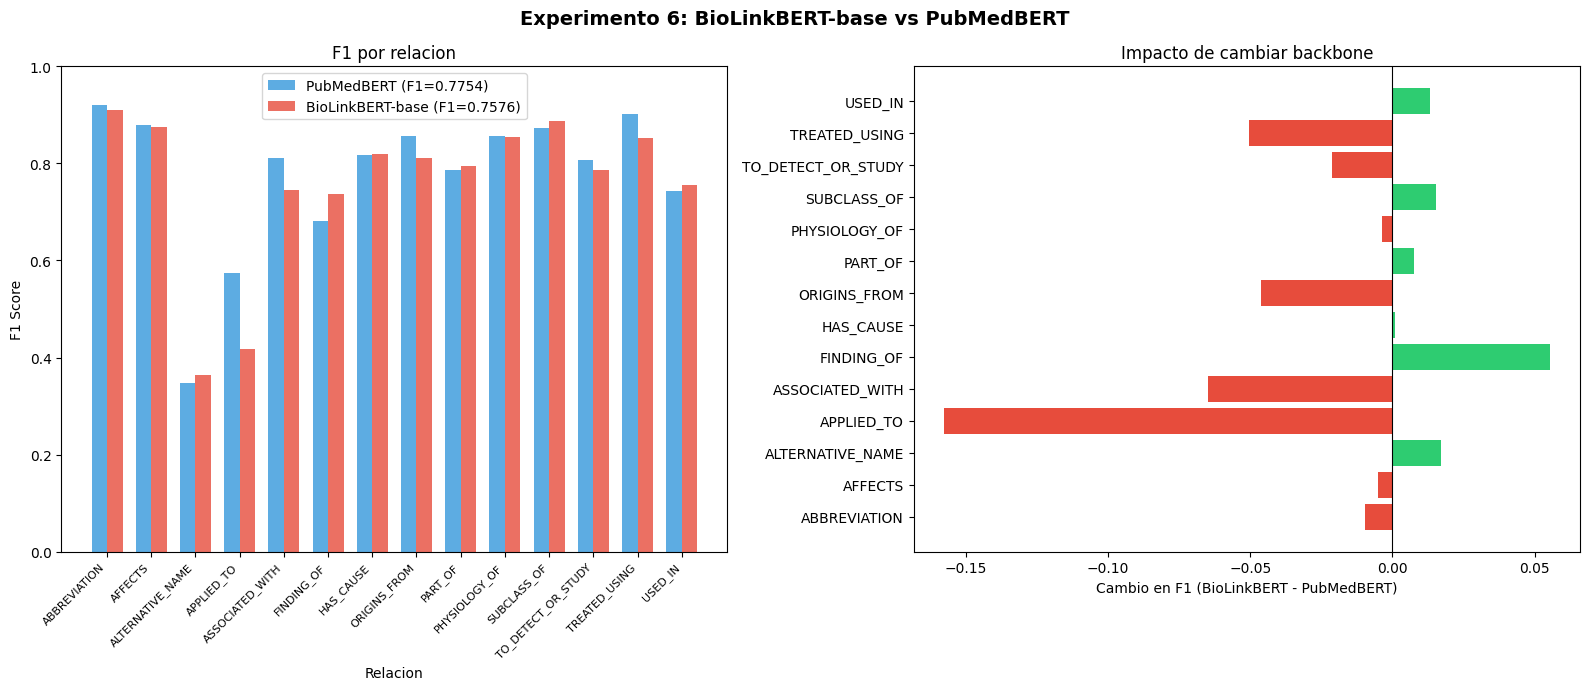

In [16]:
# Comparacion visual: BioLinkBERT vs PubMedBERT por relacion
# F1 de Exp1 (PubMedBERT 10ep)
pubmedbert_f1 = {
    "ABBREVIATION": 0.9200,
    "AFFECTS": 0.8796,
    "ALTERNATIVE_NAME": 0.3465,
    "APPLIED_TO": 0.5743,
    "ASSOCIATED_WITH": 0.8107,
    "FINDING_OF": 0.6821,
    "HAS_CAUSE": 0.8179,
    "ORIGINS_FROM": 0.8571,
    "PART_OF": 0.7862,
    "PHYSIOLOGY_OF": 0.8571,
    "SUBCLASS_OF": 0.8728,
    "TO_DETECT_OR_STUDY": 0.8072,
    "TREATED_USING": 0.9024,
    "USED_IN": 0.7421,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Experimento 6: BioLinkBERT-base vs PubMedBERT", fontsize=14, fontweight="bold")

rels_plot = [r for r in all_relations if results.get(r, {}).get("support", 0) > 0]
f1_pubmed = [pubmedbert_f1.get(r, 0) for r in rels_plot]
f1_biolink = [results[r]["f1"] for r in rels_plot]

# Barras comparativas
x = np.arange(len(rels_plot))
width = 0.35
axes[0].bar(x - width/2, f1_pubmed, width,
            label=f'PubMedBERT (F1=0.7754)', color='#3498db', alpha=0.8)
axes[0].bar(x + width/2, f1_biolink, width,
            label=f'BioLinkBERT-base (F1={macro_f1:.4f})', color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('Relacion')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 por relacion')
axes[0].set_xticks(x)
axes[0].set_xticklabels(rels_plot, rotation=45, ha='right', fontsize=8)
axes[0].legend()
axes[0].set_ylim(0, 1)

# Diferencia por relacion
diffs = [f1_biolink[i] - f1_pubmed[i] for i in range(len(rels_plot))]
colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in diffs]
axes[1].barh(rels_plot, diffs, color=colors)
axes[1].set_xlabel('Cambio en F1 (BioLinkBERT - PubMedBERT)')
axes[1].set_title('Impacto de cambiar backbone')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / f"comparacion_{EXPERIMENT_NAME}.png"), dpi=150, bbox_inches='tight')
plt.show()

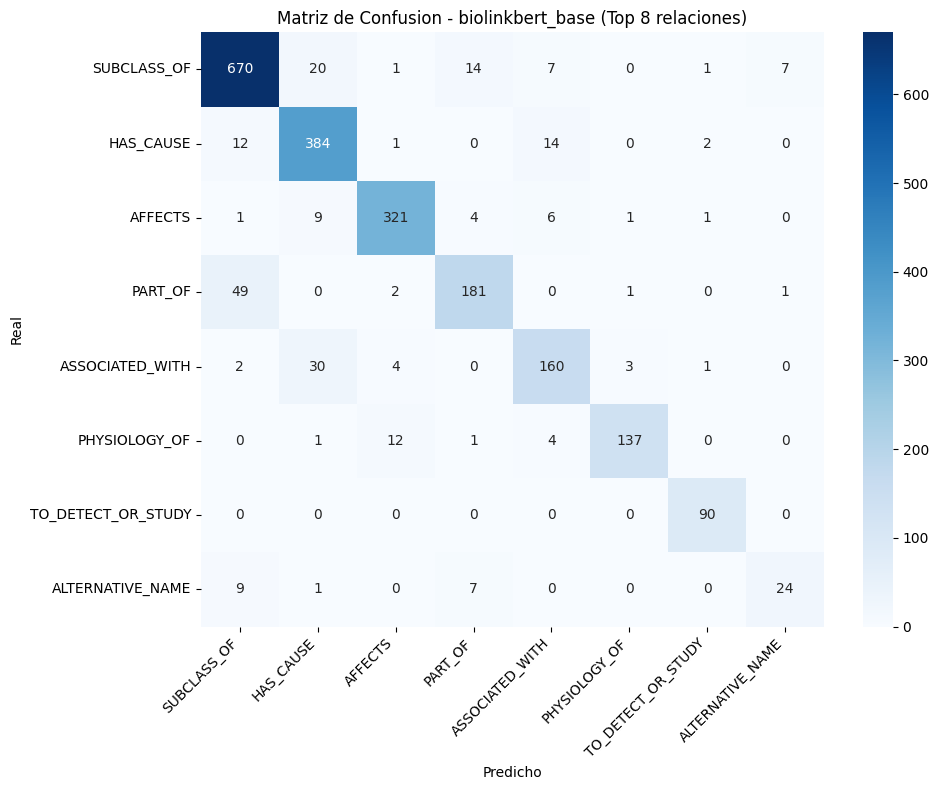

In [17]:
# Matriz de confusion
from sklearn.metrics import confusion_matrix

gold_idx = [rel2id[g] for g in gold_labels]
pred_idx = [rel2id[p] for p in pred_labels]

top_rels = [r for r, _ in Counter(gold_labels).most_common(8)]
top_indices = [rel2id[r] for r in top_rels]

cm = confusion_matrix(gold_idx, pred_idx, labels=top_indices)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_rels, yticklabels=top_rels)
plt.title(f'Matriz de Confusion - {EXPERIMENT_NAME} (Top 8 relaciones)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / f"confusion_{EXPERIMENT_NAME}.png"), dpi=150, bbox_inches='tight')
plt.show()

## 8. Guardar Resultados

In [18]:
experiment_results = {
    "experiment": EXPERIMENT_NAME,
    "model": MODEL_NAME,
    "technique": "solo cambio de backbone (datos originales, sin typed markers)",
    "hyperparameters": {
        "max_length": MAX_LENGTH,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "epochs": EPOCHS,
        "warmup_steps": WARMUP_STEPS,
        "neg_ratio": NEG_RATIO,
        "seed": SEED,
    },
    "results": {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "per_relation": results,
    },
    "comparison": {
        "baseline_macro_f1": 0.6944,
        "pubmedbert_10ep_macro_f1": 0.7754,
        "pubmedbert_typed_markers_macro_f1": 0.8078,
        "pubmedbert_typed_neg_ratio_macro_f1": 0.8430,
        "biolinkbert_base_macro_f1": macro_f1,
        "improvement_vs_baseline": macro_f1 - 0.6944,
        "improvement_vs_pubmedbert": macro_f1 - 0.7754,
    },
    "error_analysis": {
        "total_errors": total_errors,
        "error_rate": total_errors / total,
        "top_confusions": [
            {"gold": g, "pred": p, "count": c}
            for (g, p), c in confusion_pairs.most_common(10)
        ],
    },
    "n_train": n_train,
    "n_dev": n_dev,
}

results_path = OUTPUT_DIR / f"results_{EXPERIMENT_NAME}.json"
with open(results_path, "w") as f:
    json.dump(experiment_results, f, indent=2)

print(f"Resultados guardados en: {results_path}")
print(f"\nResumen final:")
print(f"  BioLinkBERT-base Macro F1: {macro_f1:.4f}")
print(f"  vs PubMedBERT: {macro_f1 - 0.7754:+.4f}")
print(f"  vs Baseline:   {macro_f1 - 0.6944:+.4f}")

Resultados guardados en: /kaggle/working/outputs/results_biolinkbert_base.json

Resumen final:
  BioLinkBERT-base Macro F1: 0.7576
  vs PubMedBERT: -0.0178
  vs Baseline:   +0.0632


## 9. Proximos Pasos

Dependiendo del resultado obtenido, hay dos direcciones posibles:

**Si BioLinkBERT-base supera a PubMedBERT:**
- Exp7: BioLinkBERT-base + typed markers + neg_ratio 1:1
  (aplicar las mismas mejoras de Exp2+Exp3 pero sobre este backbone)
- Exp8 (opcional): BioLinkBERT-**large** si la VRAM de Kaggle lo permite (333M params, batch_size=8)

**Si BioLinkBERT-base es similar o inferior a PubMedBERT:**
- Es un resultado igualmente valido para la memoria: demuestra que el dominio especifico
  (PubMedBERT) pesa mas que el preentrenamiento con links (BioLinkBERT)
- Continuar con Exp4 (focal loss) y Exp5 (class weights) sobre PubMedBERT

**Nota sobre BioLinkBERT-large:**
```python
# Para probar la version large (333M params):
MODEL_NAME = "michiyasunaga/BioLinkBERT-large"
EXPERIMENT_NAME = "biolinkbert_large"
BATCH_SIZE = 8  # reducir para caber en 15.6GB VRAM
```